In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("orders_raw.csv")
products = pd.read_csv("products.csv")

print("Orders dataset loaded successfully!")
print("Products dataset loaded successfully!")

Orders dataset loaded successfully!
Products dataset loaded successfully!


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    object 
 2   customer_name  508 non-null    object 
 3   city           508 non-null    object 
 4   category       508 non-null    object 
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    object 
 9   status         508 non-null    object 
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), object(6)
memory usage: 43.8+ KB


In [8]:
df.describe()

,order_id,product_id,quantity,amount_inr,rating
count,508.000000,508.000000,508.000000,498.000000,439.000000
mean,250.204724,15.476378,3.045276,257.530120,3.082005
std,144.594139,8.747467,1.364497,559.424136,1.364126
min,1.000000,1.000000,1.000000,20.000000,1.000000
25%,125.750000,8.000000,2.000000,90.000000,2.000000
50%,249.500000,15.000000,3.000000,168.000000,3.000000
75%,376.250000,23.000000,4.000000,283.750000,4.000000
max,500.000000,30.000000,5.000000,7600.000000,5.000000


In [9]:
df["status"].value_counts()

status
Delivered    439
Cancelled     43
Pending       26
Name: count, dtype: int64

In [10]:
df.head()

,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating
0,1,2026-03-09,Dev,Pune,Snacks & Beverages,13,5,175.0,UPI,Delivered,5.0
1,2,2026-05-22,Ayaan,Bengaluru,Snacks & Beverages,15,1,60.0,Debit Card,Delivered,5.0
2,3,2026-06-30,Yash,Bengaluru,Household Essentials,25,2,150.0,UPI,Delivered,2.0
3,4,2026-03-01,Sneha,Hyderabad,Snacks & Beverages,11,1,30.0,UPI,Delivered,4.0
4,5,2026-04-05,Rohit,Mumbai,Snacks & Beverages,14,2,220.0,Debit Card,Delivered,3.0


In [11]:
products.head()

,product_id,product_name,category,supplier,unit_price_inr
0,1,Banana 1kg,Fruits & Vegetables,FreshFarms Co,50
1,2,Tomato 1kg,Fruits & Vegetables,FreshFarms Co,40
2,3,Onion 1kg,Fruits & Vegetables,GreenValley Traders,35
3,4,Apple 1kg,Fruits & Vegetables,GreenValley Traders,180
4,5,Spinach Bunch,Fruits & Vegetables,FreshFarms Co,25


In [12]:
duplicate_count = df.duplicated(subset="order_id").sum()
print("Duplicate order IDs:", duplicate_count)

Duplicate order IDs: 8


In [13]:
print("Rows before removing duplicates:", len(df))


Rows before removing duplicates: 508


In [14]:
df = df.drop_duplicates(subset="order_id", keep="first")

In [15]:
print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 500


In [16]:
print("Cities before cleaning:")
print(df["city"].unique())

print("\nCategories before cleaning:")
print(df["category"].unique())

Cities before cleaning:
['Pune' 'Bengaluru' 'Hyderabad' 'Mumbai' ' Bengaluru ' 'BENGALURU'
 ' Mumbai ' 'HYDERABAD' 'mumbai' 'MUMBAI' ' Pune ' ' Hyderabad '
 'bengaluru' 'PUNE']

Categories before cleaning:
['Snacks & Beverages' 'Household Essentials' 'Bakery' 'Personal Care'
 'Fruits & Vegetables' 'Dairy & Eggs' ' Dairy & Eggs ' 'BAKERY'
 ' Household Essentials ' 'DAIRY & EGGS' ' Bakery ' 'SNACKS & BEVERAGES'
 'dairy & eggs' 'HOUSEHOLD ESSENTIALS' ' Personal Care '
 'FRUITS & VEGETABLES' ' Fruits & Vegetables ' 'snacks & beverages']


In [17]:
df["city"] = df["city"].str.strip().str.title()

In [18]:
df["category"] = df["category"].str.strip().str.title()

In [19]:
print("Unique cities:")
print(sorted(df["city"].unique()))

print("Number of unique cities:", df["city"].nunique())

Unique cities:
['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune']
Number of unique cities: 4


In [20]:
print("Unique categories:")
print(sorted(df["category"].unique()))

print("Number of unique categories:", df["category"].nunique())

Unique categories:
['Bakery', 'Dairy & Eggs', 'Fruits & Vegetables', 'Household Essentials', 'Personal Care', 'Snacks & Beverages']
Number of unique categories: 6


## City and Category Cleaning

City and category values were cleaned using `.str.strip().str.title()` to remove
unwanted whitespace and standardize capitalization.

After cleaning, the city column contains exactly 4 canonical values:
Bengaluru, Hyderabad, Mumbai and Pune.

The category column contains exactly 6 canonical category values:
Bakery, Dairy & Eggs, Fruits & Vegetables, Household Essentials, Personal Care
and Snacks & Beverages.

In [21]:
missing_amounts = df["amount_inr"].isna().sum()

print("Missing amount_inr values:", missing_amounts)

Missing amount_inr values: 10


In [22]:
df["amount_inr"] = pd.to_numeric(df["amount_inr"], errors="coerce")

In [23]:
print(df["amount_inr"].isna().sum())

10


In [24]:
df[df["amount_inr"].isna()][
    ["order_id", "status", "quantity", "amount_inr"]
]

,order_id,status,quantity,amount_inr
33,34,Delivered,4,NaN
35,36,Delivered,5,NaN
113,114,Pending,5,NaN
231,232,Delivered,5,NaN
268,269,Delivered,3,NaN
287,288,Delivered,5,NaN
304,305,Delivered,3,NaN
332,333,Delivered,1,NaN
365,366,Delivered,4,NaN
414,415,Delivered,3,NaN


In [25]:
df["amount_inr"].fillna(...)

0      175.0
1       60.0
2      150.0
3       30.0
4      220.0
       ...  
495     80.0
496    200.0
497    100.0
498    390.0
499     25.0
Name: amount_inr, Length: 500, dtype: object

In [26]:
delivered = df[
    (df["status"] == "Delivered") &
    (df["amount_inr"].notna())
].copy()

print("Delivered orders with valid amount:", len(delivered))

Delivered orders with valid amount: 425


In [27]:
Q1 = delivered["amount_inr"].quantile(0.25)
Q3 = delivered["amount_inr"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 90.0
Q3: 275.0
IQR: 185.0


In [28]:
upper_fence = Q3 + 1.5 * IQR

print("Upper Fence:", upper_fence)

Upper Fence: 552.5


In [29]:
outliers = df[
    df["amount_inr"].notna() &
    (df["amount_inr"] > upper_fence)
]

print("Number of values above upper fence:", len(outliers))

Number of values above upper fence: 21


In [30]:
outliers[
    ["order_id", "amount_inr", "status", "quantity"]
].sort_values("amount_inr", ascending=False)

,order_id,amount_inr,status,quantity
322,323,7600.0,Delivered,2
198,199,5400.0,Delivered,3
249,250,5200.0,Delivered,1
172,173,4800.0,Pending,2
255,256,4400.0,Cancelled,2
213,214,1100.0,Delivered,5
395,396,900.0,Delivered,5
333,334,720.0,Delivered,4
151,152,720.0,Cancelled,4
221,222,660.0,Delivered,3


In [31]:
before_cap = df["amount_inr"].copy()

In [32]:
df["amount_inr"] = df["amount_inr"].clip(upper=upper_fence)

In [33]:
capped_count = (
    before_cap.notna() &
    (before_cap > upper_fence)
).sum()

print("Number of capped values:", capped_count)

Number of capped values: 21


In [34]:
print("Maximum amount after capping:", df["amount_inr"].max())
print("Upper fence:", upper_fence)

Maximum amount after capping: 552.5
Upper fence: 552.5


In [35]:
before_cap = df["amount_inr"].copy()

In [36]:
df["amount_inr"] = df["amount_inr"].clip(upper=upper_fence)

In [37]:
capped_count = (
    before_cap.notna() &
    (before_cap > upper_fence)
).sum()

print("Number of capped values:", capped_count)

Number of capped values: 0


In [38]:
print("Maximum amount after capping:", df["amount_inr"].max())
print("Upper fence:", upper_fence)

Maximum amount after capping: 552.5
Upper fence: 552.5


In [39]:
raw_check = pd.read_csv("orders_raw.csv")

raw_check = raw_check.drop_duplicates(
    subset="order_id",
    keep="first"
)

raw_check["amount_inr"] = pd.to_numeric(
    raw_check["amount_inr"],
    errors="coerce"
)

print("Rows in original cleaned raw data:", len(raw_check))

Rows in original cleaned raw data: 500


In [40]:
before_cap = raw_check["amount_inr"].copy()

In [41]:
capped_count = (
    before_cap.notna() &
    (before_cap > upper_fence)
).sum()

print("Number of values above upper fence:", capped_count)

Number of values above upper fence: 21


In [42]:
capped_count = (
    before_cap.notna() &
    (before_cap > upper_fence)
).sum()

print("Number of values above upper fence:", capped_count)

Number of values above upper fence: 21


In [43]:
df["amount_inr"] = df["amount_inr"].clip(upper=upper_fence)

In [44]:
print("Maximum amount after capping:", df["amount_inr"].max())
print("Upper fence:", upper_fence)

Maximum amount after capping: 552.5
Upper fence: 552.5


In [45]:
print("Number of values above upper fence:", capped_count)

Number of values above upper fence: 21


In [46]:
df["order_date"] = pd.to_datetime(df["order_date"])

df["month"] = df["order_date"].dt.month

df["month_name"] = df["order_date"].dt.month_name()

df["revenue_per_unit"] = df["amount_inr"] / df["quantity"]

df["is_delivered"] = df["status"] == "Delivered"

In [47]:
print(df[
    [
        "order_date",
        "month",
        "month_name",
        "quantity",
        "amount_inr",
        "revenue_per_unit",
        "status",
        "is_delivered"
    ]
].head())

  order_date  month month_name  quantity  amount_inr  revenue_per_unit  \
0 2026-03-09      3      March         5       175.0              35.0   
1 2026-05-22      5        May         1        60.0              60.0   
2 2026-06-30      6       June         2       150.0              75.0   
3 2026-03-01      3      March         1        30.0              30.0   
4 2026-04-05      4      April         2       220.0             110.0   

      status  is_delivered  
0  Delivered          True  
1  Delivered          True  
2  Delivered          True  
3  Delivered          True  
4  Delivered          True  


In [48]:
category_revenue = (
    df[(df["is_delivered"]) & (df["amount_inr"].notna())]
    .groupby("category")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

print(category_revenue)

print("\nTop category:", category_revenue.idxmax())
print("Top category revenue:", category_revenue.max())

category
Household Essentials    20910.0
Bakery                  14975.0
Personal Care           14594.5
Dairy & Eggs            13675.0
Snacks & Beverages      11312.5
Fruits & Vegetables      9170.0
Name: amount_inr, dtype: float64

Top category: Household Essentials
Top category revenue: 20910.0


In [49]:
merged = pd.merge(
    df,
    products,
    on="product_id",
    how="left"
)

supplier_revenue = (
    merged[
        (merged["is_delivered"]) &
        (merged["amount_inr"].notna())
    ]
    .groupby("supplier")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

print(supplier_revenue)

print("\nTop supplier:", supplier_revenue.idxmax())
print("Top supplier revenue:", supplier_revenue.max())

supplier
HomeEssentials Traders    20910.0
BakeHouse Supplies        18550.0
CarePlus Distributors     14594.5
DairyBest Ltd             10710.0
SnackHub India             7737.5
FreshFarms Co              5490.0
GreenValley Traders        3680.0
CountryEggs Farms          2965.0
Name: amount_inr, dtype: float64

Top supplier: HomeEssentials Traders
Top supplier revenue: 20910.0


In [50]:
sql_top_category = "Household Essentials"
sql_top_supplier = "HomeEssentials Traders"

print("Part 1 SQL top category:", sql_top_category)
print("Part 4 Pandas top category:", category_revenue.idxmax())

print("\nCategory matches:",
      category_revenue.idxmax() == sql_top_category)

print("\nPart 1 SQL top supplier:", sql_top_supplier)
print("Part 4 Pandas top supplier:", supplier_revenue.idxmax())

print("\nSupplier matches:",
      supplier_revenue.idxmax() == sql_top_supplier)

Part 1 SQL top category: Household Essentials
Part 4 Pandas top category: Household Essentials

Category matches: True

Part 1 SQL top supplier: HomeEssentials Traders
Part 4 Pandas top supplier: HomeEssentials Traders

Supplier matches: True


## Cross-Validation with Part 1 SQL

The cleaned Pandas analysis independently identifies Household Essentials as the
top category and HomeEssentials Traders as the top supplier, matching the
required Part 1 SQL control findings.

Exact revenue totals may differ from Part 1 SQL because Part 4 uses the raw
dataset after duplicate removal, missing-value exclusion and IQR-based capping.

## Date and Derived Columns

The `order_date` column was converted to datetime format using `pd.to_datetime()`.

The following derived columns were created:

- `month` – numerical month extracted from the order date
- `month_name` – month name extracted from the order date
- `revenue_per_unit` – order amount divided by quantity
- `is_delivered` – Boolean indicator identifying Delivered orders

The `revenue_per_unit` calculation uses the capped `amount_inr` values.

## IQR Outlier Detection and Capping

Outliers were identified using the Interquartile Range (IQR) method on Delivered
orders with non-null `amount_inr` values.

The upper fence was calculated as:

Upper Fence = Q3 + 1.5 × IQR

The calculated upper fence was ₹552.50.

Values above the upper fence were treated as suspicious high-value observations.
Instead of deleting these observations, the values were capped at the upper fence
using `.clip(upper=upper_fence)`. This preserves the order records while reducing
the influence of extreme values on revenue calculations.

Missing `amount_inr` values were not filled and remain excluded from revenue
calculations.

## Missing Amount Values

There are 10 missing values in the `amount_inr` column.

The missing revenue amounts were not filled or estimated because doing so could
introduce artificial revenue into the analysis. The values remain as `NaN` and
the affected rows will be excluded from revenue calculations.

Rating nulls associated with Cancelled or Pending orders are treated as legitimate
missing values and are not filled.

## Duplicate Removal

The raw dataset contained 508 rows, including 8 duplicate order records.

Duplicates were identified using `order_id` and removed using `drop_duplicates()`, keeping the first occurrence of each order.

After cleaning, the dataset contains exactly 500 unique orders.

## Initial Data Quality Assessment

The raw orders dataset contains deliberately introduced data-quality issues.

The dataset contains more than 500 rows because duplicate order records were added. 
There are also mixed casing and whitespace in city and category values, missing values in 
amount_inr, and suspiciously large amount values that require outlier treatment.

These issues will be cleaned and validated before performing the final diagnostic analysis.

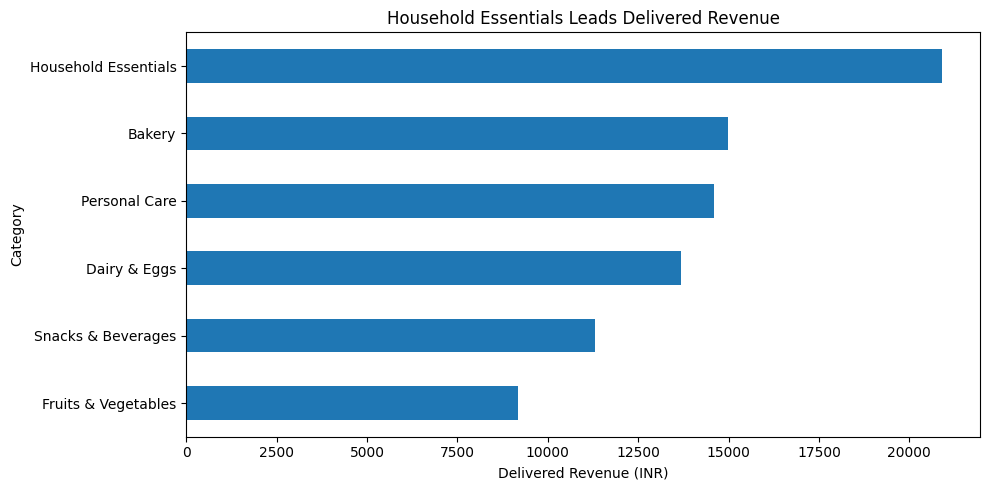

In [51]:
plt.figure(figsize=(10, 5))

category_revenue.sort_values().plot(kind="barh")

plt.title("Household Essentials Leads Delivered Revenue")
plt.xlabel("Delivered Revenue (INR)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

In [52]:
monthly_revenue = (
    df[(df["is_delivered"]) & (df["amount_inr"].notna())]
    .groupby("month_name")["amount_inr"]
    .sum()
    .reindex([
        "January",
        "February",
        "March",
        "April",
        "May",
        "June"
    ])
)

print(monthly_revenue)

month_name
January     10059.5
February    13715.0
March       14747.5
April       16558.5
May         16668.5
June        12888.0
Name: amount_inr, dtype: float64


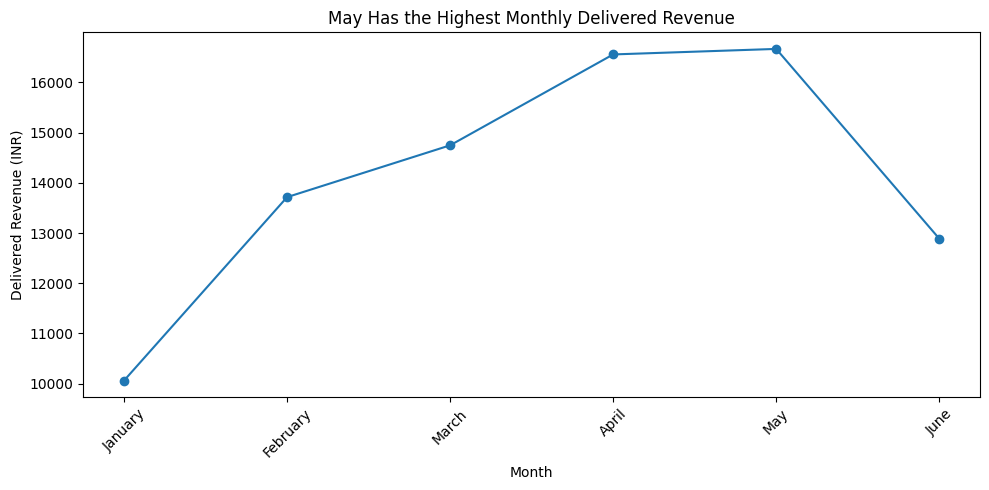

In [53]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o"
)

plt.title("May Has the Highest Monthly Delivered Revenue")
plt.xlabel("Month")
plt.ylabel("Delivered Revenue (INR)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

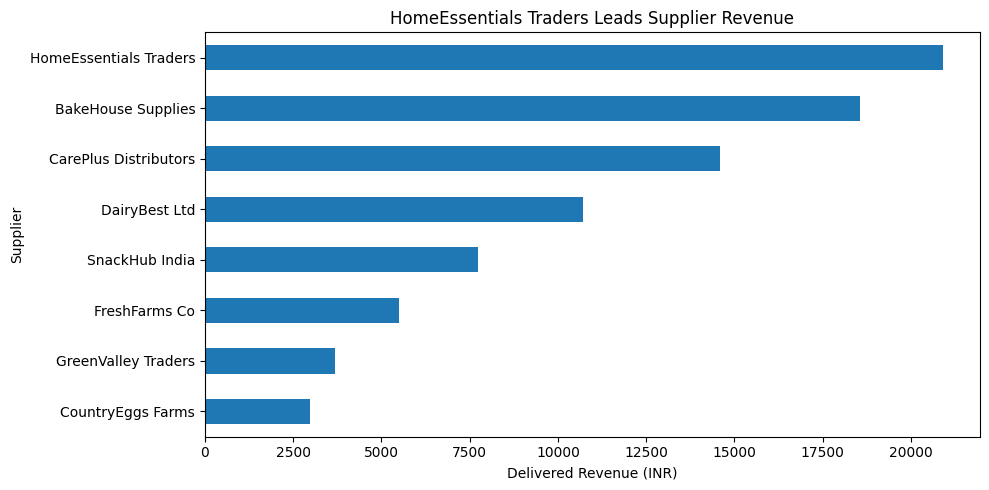

In [54]:
top_suppliers = supplier_revenue.head(8).sort_values()

plt.figure(figsize=(10, 5))

top_suppliers.plot(kind="barh")

plt.title("HomeEssentials Traders Leads Supplier Revenue")
plt.xlabel("Delivered Revenue (INR)")
plt.ylabel("Supplier")

plt.tight_layout()
plt.show()

## Three Diagnostic Insights

### Insight 1: Household Essentials is the strongest category

**What:** Household Essentials generated the highest delivered revenue at
₹20,910.00 after cleaning and IQR capping.

**Why it matters:** This category is the strongest revenue contributor and
continues to be the top category identified in the Part 1 SQL analysis.

**Next step:** Maintain product availability and supplier capacity for
Household Essentials while exploring opportunities to increase its sales further.

### Insight 2: May is the peak revenue month

**What:** May recorded the highest delivered revenue at ₹16,668.50, while
January recorded the lowest at ₹10,059.50.

**Why it matters:** Revenue increased substantially from the beginning of the
period and reached its highest point in May before declining in June.

**Next step:** Investigate the products, categories, promotions or customer
activity that contributed to the May peak and consider applying successful
strategies to lower-performing months.

### Insight 3: HomeEssentials Traders is the leading supplier

**What:** HomeEssentials Traders generated the highest delivered supplier
revenue at ₹20,910.00 after cleaning and IQR capping.

**Why it matters:** The leading supplier contributes strongly to the
highest-performing category, Household Essentials.

**Next step:** Monitor the supplier's inventory and fulfillment performance
and evaluate whether its strong performance can be sustained.